In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd # For mapping
import matplotlib.pyplot as plt
from matplotlib import cm # Colormap to be used in mapping
# For basemap
import contextily as cx
import geodatasets as geodata

In [6]:
# Reading in the IUCN Red List Data
iucn = pd.read_csv("../data/assessments.csv")
# Only selecting the Scientific Name and Red List Category for this project
# Other columns are not needed
iucn = iucn[["scientificName", "redlistCategory"]]
# iucn.head()
# iucn.shape

In [7]:
# Reading in the Roadkill data
roadkill = pd.read_csv("../data/Data_S6_Spatial_analysis_and_land_cover.csv")
# roadkill.head()

In [4]:
# Step-by-step demonstration of the Data Cleaning Process and different cases to address
# This bird has Family and Species missing
roadkill[roadkill["Code"] == "D60CO126"]
# Find the most common family for the known order
roadkill[roadkill['Order'] ==  "Passeriformes"]['Family'].value_counts()
# Find the most common species for the most common family found
roadkill[roadkill['Family'] ==  'Emberizidae']['Species'].value_counts()
# Example of a family for which the species for missing in all instances
roadkill[roadkill["Family"] == "Cricetidae"].head()
# Example of a species for which only genus is listed
roadkill[roadkill["Species"] == "Caecilia sp."].head()

,Code,mmddyy,Road_segement,Class,Order,Family,Species,UTMzone,Xcoordinate,Ycoordinate,Time,Altitud_m,Land_cover
33,D39CO83,5/30/14,Cotundo,Amphibia,Gymnophiona,Caeciliidae,Caecilia sp.,18M,180454,9947497,15:55,1845,F
43,D15CO19,7/4/2014,Cotundo,Amphibia,Gymnophiona,Caeciliidae,Caecilia sp.,18M,184753,9931085,15:12,2233,F
44,D7CO10,12/3/2014,Cotundo,Amphibia,Gymnophiona,Caeciliidae,Caecilia sp.,18M,184984,9931163,14:58,2223,F
76,D60CO127,7/26/14,Cotundo,Amphibia,Gymnophiona,Caeciliidae,Caecilia sp.,18M,180228,9945686,11:06,1878,S/F
83,D39CO85,5/30/14,Cotundo,Amphibia,Gymnophiona,Caeciliidae,Caecilia sp.,18M,180532,9947583,16:01,1866,U/F


In [5]:
# How many species are which values and which levels of taxonomy?
roadkill.isna().sum()

Code              0
mmddyy            0
Road_segement     0
Class             0
Order            24
Family           61
Species          97
UTMzone           0
Xcoordinate       0
Ycoordinate       0
Time              0
Altitud_m         0
Land_cover        0
dtype: int64

In [6]:
# Source: https://www.sciencedirect.com/science/chapter/edited-volume/pii/B9780128053065000304
# This is an odd case where the Family was present but the order was not
# Knowing the family, we should know the order, so I researched this and replaced it
roadkill.loc[302, 'Order'] = "Falconiformes"

In [7]:
# roadkill[roadkill['Species'] == 'N/I'].head()
# roadkill[roadkill['Order'] == 'N/I'].head()
# Some of the rows contain "N/I" which needs to be replaced with NA
roadkill = roadkill.replace('N/I', pd.NA)
roadkill = roadkill.replace(np.nan, pd.NA)

In [8]:
# This block contains pseudocode for the data cleaning process
# Note that the Class was identified for all of the roadkill, so we can stop the algorithm at order

# for each row that has a null value
# if species is null
# if the family is not-null take the family
        # find the most common species for that family 
    # if species and family is null
        # find the most common family for that order, and the most common species within that family
    # if the species and family and order is null, find the most common order for the class, the most common family for that order and most common species for that family

In [9]:
# Algorithm for replacing missing values with the most common value within the dataset based on what is missing

for idx, animal in roadkill.iterrows(): # For each row index / animal in the data roadkill data frame
    if pd.isna(animal['Species']): # if species is missing
        if pd.isna(animal['Family']): # and if the family is missing
            if pd.isna(animal['Order']): # and if the order is missing
                animal_class = animal['Class'] # take the class of the animal
                # if there is at least one roadkill instance in this class for which we know the order
                if (roadkill[roadkill['Class'] ==  animal_class]['Order'].value_counts().size > 0):
                   # find the most common order for the class
                   most_common_order = roadkill[roadkill['Class'] ==  animal_class]['Order'].mode()[0]
                   # set the order of the current animal to the most common order
                   roadkill.loc[idx,'Order'] = most_common_order
                   # if there is at least one roadkill instance in this order for which we know the family
                   if (roadkill[roadkill['Order'] ==  most_common_order]['Family'].value_counts().size > 0):
                       # find the most common family for the order
                       most_common_family = roadkill[roadkill['Order'] ==  most_common_order]['Family'].mode()[0]
                       # set the order of the current animal to the most common family
                       roadkill.loc[idx,'Family'] = most_common_family
                       # if there is at least one roadkill instance in this family for which we know the species
                       if (roadkill[roadkill['Family'] ==  most_common_family]['Species'].value_counts().size > 0):
                           # find the most common species for the family
                           most_common_species = roadkill[roadkill['Family'] ==  most_common_family]['Species'].mode()[0]
                           # set the species of the current animal to the most common species
                           roadkill.loc[idx,'Species'] = most_common_species
            else: # species and family are missing but we have the order
                # find the most common family for that order, and the most common species within that family
                animal_order = animal['Order'] # take the order of the animal
                # if there is at least one roadkill instance in this order for which we know the family
                if (roadkill[roadkill['Order'] ==  animal_order]['Family'].value_counts().size > 0):
                       # find the most common family the order
                       most_common_family = roadkill[roadkill['Order'] ==  animal_order]['Family'].mode()[0]
                       # set the family of the current animal to the most common family
                       roadkill.loc[idx,'Family'] = most_common_family
                       # if there is at least one roadkill instance in this family for which we know the species
                       if (roadkill[roadkill['Family'] ==  most_common_family]['Species'].value_counts().size > 0):
                           # find the most common species for the family
                           most_common_species = roadkill[roadkill['Family'] ==  most_common_family]['Species'].mode()[0]
                           # set the species of the current animalt to the most common species
                           roadkill.loc[idx, 'Species'] = most_common_species
        else: # species is missing but we have the family
            animal_family = animal['Family'] # take the family of the current species
            # if there is at least one roadkill instance in this family for which we know the species
            if (roadkill[roadkill['Family'] ==  animal_family]['Species'].value_counts().size > 0):
                # find the most common species for the family
                most_common_species = roadkill[roadkill['Family'] ==  animal_family]['Species'].mode()[0]
                # set the species of the current animalt to the most common species
                roadkill.loc[idx, 'Species'] = most_common_species

In [10]:
# Are there still any missing values?
roadkill.isna().sum()
# 25 species are still missing there values!

Code              0
mmddyy            0
Road_segement     0
Class             0
Order             0
Family            0
Species          25
UTMzone           0
Xcoordinate       0
Ycoordinate       0
Time              0
Altitud_m         0
Land_cover        0
dtype: int64

In [11]:
# Let's investigate the rows that are still missing...
# For these, the species is missing for all instances of the family
without_nulls = roadkill[pd.isna(roadkill['Species']) == False]
still_missing = roadkill[pd.isna(roadkill['Species'])]
still_missing.drop_duplicates(subset=["Family"], keep="last")

,Code,mmddyy,Road_segement,Class,Order,Family,Species,UTMzone,Xcoordinate,Ycoordinate,Time,Altitud_m,Land_cover
35,D72CO155,8/21/14,Cotundo,Mammalia,Chiroptera,Vespertilionidae,<NA>,18M,180876,9947768,9:59,1875,F
180,D52CO114,5/7/2014,Cotundo,Aves,Apodiformes,Trochilidae,<NA>,18M,179024,9948599,10:31,1899,C
259,D72CO154,8/21/14,Cotundo,Mammalia,Chiroptera,Molossidae,<NA>,18M,179160,9948600,9:49,1900,P
294,D5CO9,10/3/2014,Cotundo,Aves,Passeriformes,Tyrannidae,<NA>,18M,179797,9944523,12:48,1831,P
302,D64CH193,8/8/2014,Chaco,Aves,Falconiformes,Cathartidae,<NA>,18M,180183,9950468,14:29,1852,P
352,D15CH39,7/4/2014,Chaco,Aves,Falconiformes,Accipitridae,<NA>,18M,184536,9955372,16:33,1664,P
394,D49PA77,6/22/14,Papallacta,Mammalia,Rodentia,Cricetidae,<NA>,18M,174027,9948962,15:13,1915,P/S
414,D39CO81,5/30/14,Cotundo,Mammalia,Rodentia,Echimyidae,<NA>,18M,179894,9937800,14:31,1920,P/F


In [12]:
# Want to change from the scientific name to the common name so that it is easier to read
class_map = {
    "Mammalia": 'Mammals',
    "Aves": "Birds",
    "Amphibia": 'Amphibians',
    'Reptilia': 'Reptiles'
}
roadkill['Class'] = roadkill['Class'].map(class_map) # replaces class name in the data frame with the name defined above
# roadkill.head()

In [13]:
# Preparing the Red List data frame to merge with the Roadkill data frame

# rename the column so that it matches the name in the Roadkill data frame
iucn = iucn.rename(columns={"scientificName": "Species"})
# Perform a left join on roadkill with iucn, so we get the endangered category for roadkill with complete information
combined = roadkill.merge(iucn, on="Species", how="left")
# combined.head()
# How many animals were we able to match with the merge and in which red list category?
combined['redlistCategory'].value_counts()

redlistCategory
Least Concern    254
Vulnerable         1
Name: count, dtype: int64

In [14]:
# Which species is the one vulnerable one?
combined[combined["redlistCategory"] == "Vulnerable"]

,Code,mmddyy,Road_segement,Class,Order,Family,Species,UTMzone,Xcoordinate,Ycoordinate,Time,Altitud_m,Land_cover,redlistCategory
23,D67PA103,8/15/14,Papallacta,Mammals,Carnivora,Felidae,Leopardus tigrinus,18M,174748,9948871,12:06,1884,F,Vulnerable


(array([0, 1, 2]),
 [Text(0, 0, 'Chaco'), Text(1, 0, 'Cotundo'), Text(2, 0, 'Papallacta')])

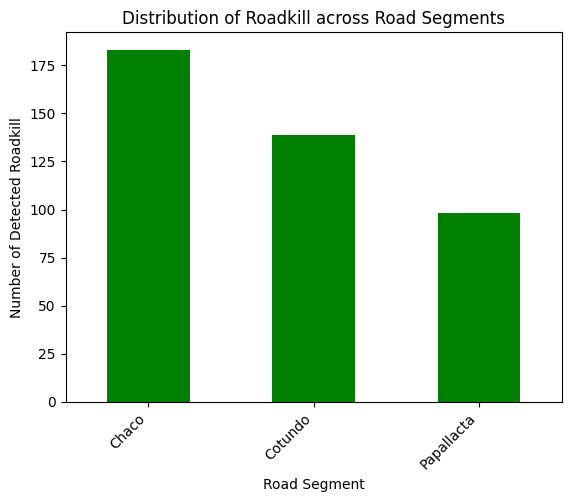

In [15]:
# How are the roadkill instances distributed among the 3 road segments?
tmp=combined.groupby(by="Road_segement")['Species'].count() # Group by Roadsegments, Take one column, species to get the row count we want to see
plot = tmp.plot(kind = 'bar', color = "green") # bar plot with green bars
# Labels and specifications for bar chart
plot.set_xlabel('Road Segment')
plot.set_ylabel('Number of Detected Roadkill')
plot.set_title('Distribution of Roadkill across Road Segments')
plt.xticks(rotation=45, ha='right')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Amphibians'),
  Text(1, 0, 'Birds'),
  Text(2, 0, 'Mammals'),
  Text(3, 0, 'Reptiles')])

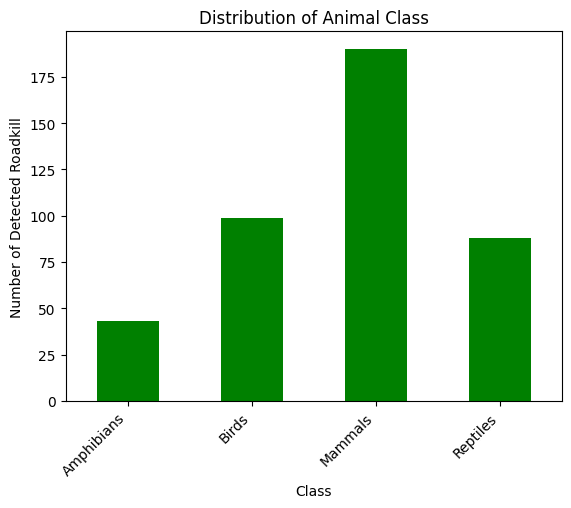

In [16]:
# How is the class taxonomy distributed among the roadkill instances?
tmp=combined.groupby(by="Class")["Species"].count() # group by the class and count number of species within each class
# Labels and specifications for the bar graph
plot = tmp.plot(kind = 'bar', color = "green")
plot.set_xlabel('Class')
plot.set_ylabel('Number of Detected Roadkill')
plot.set_title('Distribution of Animal Class')
plt.xticks(rotation=45, ha='right')

(array([0, 1]), [Text(0, 0, 'Least Concern'), Text(1, 0, 'Vulnerable')])

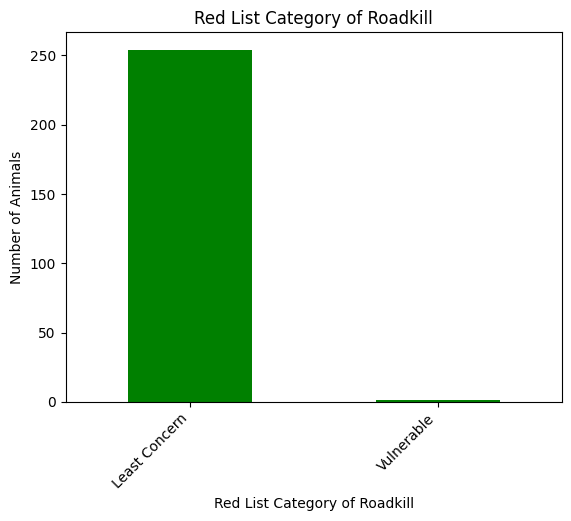

In [30]:
# How is the red list category distributed among the roadkill for which it was available?
tmp=combined.groupby(by="redlistCategory")["Species"].count()
# Labels and specifications for the bar graph
plot = tmp.plot(kind = 'bar', legend = False, color = "green")
plot.set_xlabel('Red List Category of Roadkill')
plot.set_ylabel('Number of Animals')
plot.set_title('Red List Category of Roadkill')
plt.xticks(rotation=45, ha='right')

In [18]:
# pd.set_option('display.max_rows', None)

In [19]:
# To visualize the data on a map, I need to to first split the data between points in zones UTM 17M and UTM 18M
roadkill_17 = combined[combined["UTMzone"] == "17M"]
roadkill_18 = combined[combined["UTMzone"] == "18M"]
# Turn both into a geodata frame, using the correspondign CRS number
geo_17 = gpd.GeoDataFrame(roadkill_17, geometry=gpd.points_from_xy(roadkill_17.Xcoordinate, roadkill_17.Ycoordinate), crs = "EPSG:32717")
geo_18 = gpd.GeoDataFrame(roadkill_18, geometry=gpd.points_from_xy(roadkill_18.Xcoordinate, roadkill_18.Ycoordinate), crs = "EPSG:32718")

In [20]:
# Convert both data frames to Mercator
geo_17 = geo_17.to_crs("EPSG:3857")
geo_18 = geo_18.to_crs("EPSG:3857")

In [21]:
# Combine both data frames into one
geo_17_18 = pd.concat([geo_17, geo_18])

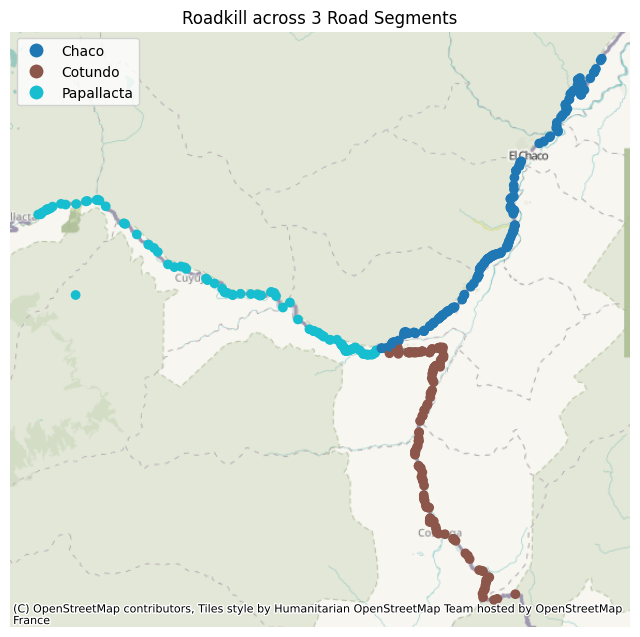

In [27]:
# Plot the points, with different colors for the road segments
ax = geo_17_18.plot(figsize=(8, 8), column = "Road_segement", legend = True)
cx.add_basemap(ax)
ax.set_title("Roadkill across 3 Road Segments")
ax.set_axis_off();


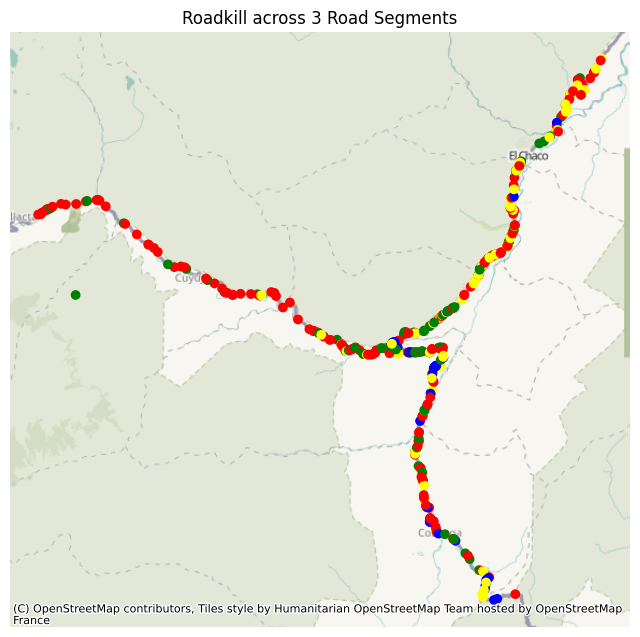

In [28]:
# Create a column color with colors defined for each class for the purpose of mapping
geo_17_18["color"] = geo_17_18['Class'].map({'Birds':"green", 'Amphibians': "blue", 'Mammals': 'red', 'Reptiles': 'yellow'})

# Plot the points, with different colors for the animal class, using the colors defined earlier
ax = geo_17_18.plot(figsize=(8, 8), color = geo_17_18['color'])
cx.add_basemap(ax)
ax.set_title("Roadkill across 3 Road Segments")
ax.set_axis_off();

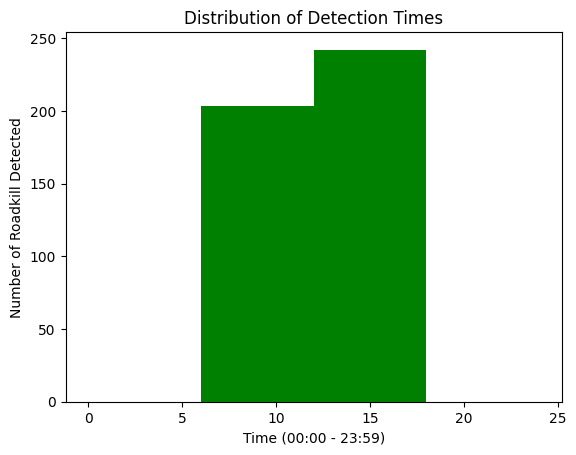

In [34]:
# How are the roadkill detection times distributed?
# Convert the dates into Date Time format, take the hour and save it in a new column called hour
combined['hour'] = pd.to_datetime(combined['Time'], format="%H:%M").dt.hour

# Define bins for the histogram
bins = [0, 6, 12, 18, 24]
# Labels and specifications for the histogram
plt.hist(combined['dates'], bins, color = "green")
plt.title("Distribution of Detection Times")
plt.xlabel("Time (00:00 - 23:59)")
plt.ylabel("Number of Roadkill Detected");

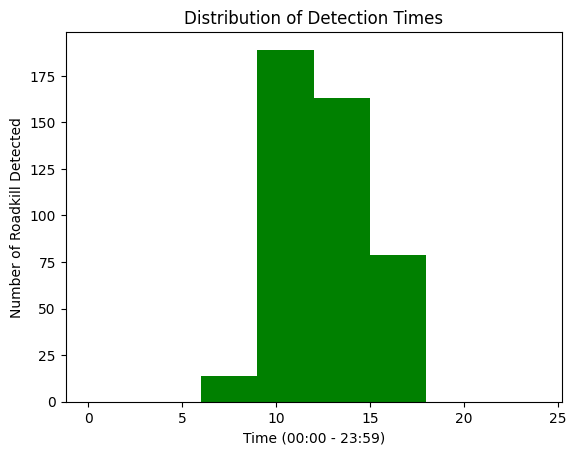

In [35]:
# Histogram of the same data but with more granular bins
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
plt.hist(combined['dates'], bins, color = "green")
plt.title("Distribution of Detection Times")
plt.xlabel("Time (00:00 - 23:59)")
plt.ylabel("Number of Roadkill Detected");